In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

In [2]:
data=pd.read_csv("data.csv")

In [3]:
data.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
202313,134266.0,-0.443348,0.611403,-0.087867,-0.726684,0.981733,-0.611900,0.995681,-0.114031,0.134287,...,-0.191817,-0.380728,0.263747,0.460540,-0.754158,0.134664,0.277072,0.258235,16.60,0
130826,79440.0,-0.565253,1.135793,0.700001,-0.365086,0.570830,-0.022358,0.554677,0.182196,-0.312826,...,-0.326298,-0.849963,-0.125168,-0.905927,0.008703,0.134147,0.347764,0.135599,9.99,0
210696,138089.0,-0.900625,-1.584555,-0.008914,-2.625588,1.277386,0.472026,-1.096204,0.226630,-1.576170,...,-0.082880,0.473135,-0.223447,-2.006966,-1.031024,-0.152478,0.150138,0.242888,15.00,0
267522,162808.0,2.077887,-0.706123,-0.993141,-0.634271,-0.860167,-0.762984,-0.985420,-0.014911,-0.217773,...,0.304413,0.945954,0.106581,-0.077312,-0.203656,-0.107980,0.028934,-0.020711,19.95,0
89183,62465.0,1.397378,-0.443895,-0.089028,-0.766018,-0.672965,-0.741001,-0.298031,-0.144766,-1.213439,...,-0.420329,-0.784971,0.002868,0.022781,0.313945,1.015044,-0.083528,-0.013401,7.94,0


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

There are no missing values.

In [5]:
data.duplicated().sum()

np.int64(1081)

In [6]:
data=data.drop_duplicates()

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [9]:
data["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [10]:
data["Class"].value_counts(normalize=True)*100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

We can see that only 0.167 percent of transactions are fraudulent. Hence, the data is highly imbalanced.

In [11]:
#Time is in seconds.It's need to be conveted into hours
data["Time"]=data["Time"]/3600

In [12]:
data["Time"].describe()

count    283726.000000
mean         26.336410
std          13.189180
min           0.000000
25%          15.056875
50%          23.525694
75%          38.693889
max          47.997778
Name: Time, dtype: float64

In [13]:
data["Time"].skew()

np.float64(-0.0355806462359829)

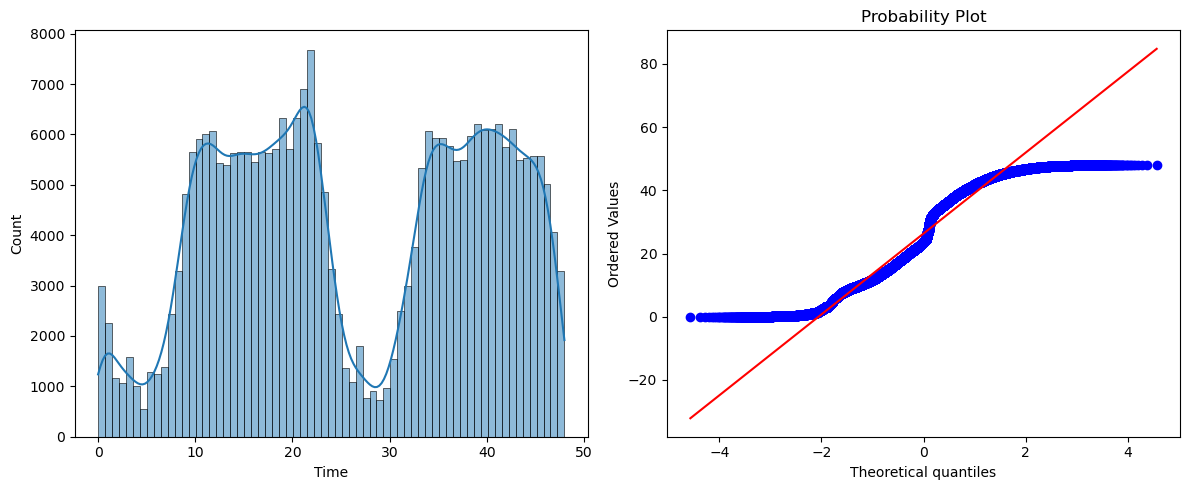

In [14]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data["Time"],kde=True)

plt.subplot(1,2,2)
stats.probplot(data["Time"],dist='norm',plot=plt)
plt.tight_layout()

In [15]:
data["Amount"].skew()

np.float64(16.978803370060476)

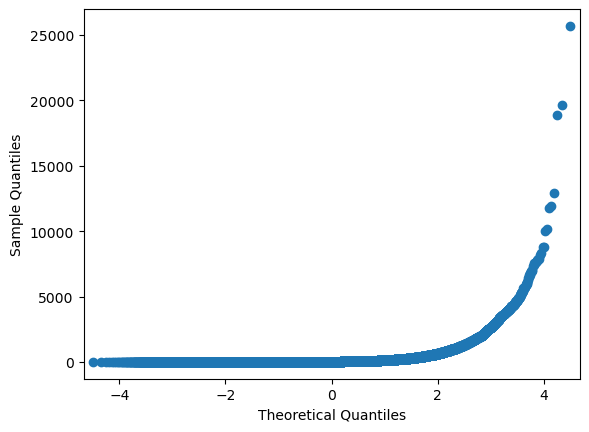

In [16]:
sm.qqplot(data["Amount"])
plt.show()

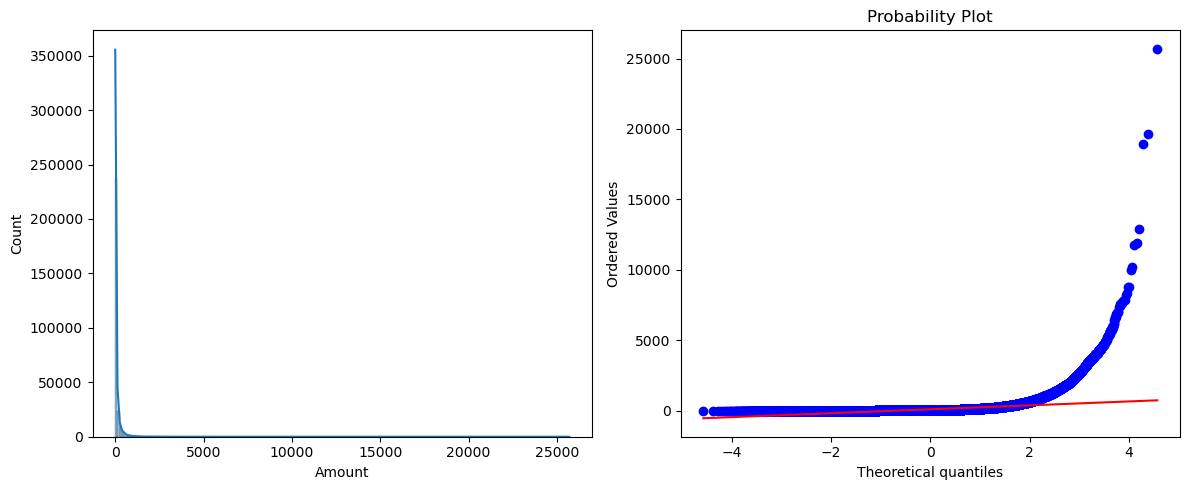

In [17]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data["Amount"],bins=200,kde=True)

plt.subplot(1,2,2)
stats.probplot(data["Amount"],dist='norm',plot=plt)
plt.tight_layout()

We can see that the Amount column is highly positively skewed.
So, we need to transform that.

In [18]:
corr=data.corr()

<Axes: >

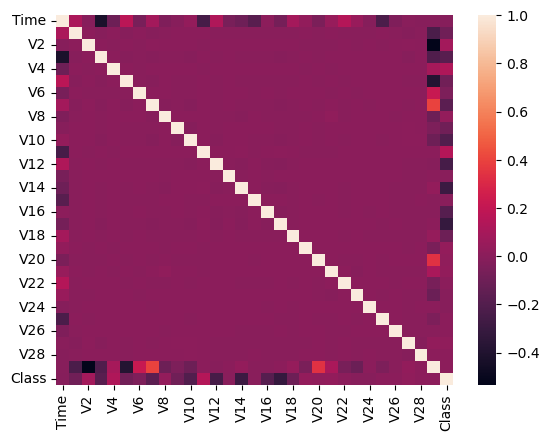

In [19]:
sns.heatmap(corr)

We can see that V28 feature correlates more than the other features.